In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("lec_act_3_plotting.ipynb")

# Lecture goals

1. Understand the difference between a figure/window and a plotting area/subplot/axes
2. Be able to create a figure with subplots in it
3. Plot something in the subplot and label it
4. Pass parameters to functions by both position and name

Note: To see what the correct result should look like, see slides https://docs.google.com/presentation/d/1IiGGUNet-4Nj07x2cTXU6IOYXy9TSdAF5OUWCCKIYEM/edit?usp=sharing


In [2]:
# Access all numpy functions as np.
import numpy as np

# Everything matplotlib-y will be plt.
import matplotlib.pyplot as plt
%matplotlib inline


# Practice plotting data

You're going to make two plots, one with the sine/cosine (like the tutorial), and a second "fun" plot. See Slides https://docs.google.com/presentation/d/1IiGGUNet-4Nj07x2cTXU6IOYXy9TSdAF5OUWCCKIYEM/edit?usp=sharing for what the first plot looks like (and a very boring plot for the second one)

# Plot 1

Read through the next few cells (up to "Plot something fun") before starting, and make sure to look at the slides for the plot you're trying to make.

The goal is to practice plotting (using sine and cosines) but also to practice writing functions to create the data and do the plot.

You'll be writing one function to make a 3xn matrix of data, another function to plot the data, then you'll make a figure and and call those functions to do the actual plotting.

In [3]:
# TODO Write a function that takes in how many samples to create, and outputs a 3xn_samples matrix
#  with t-values in the first row, cos(t) in the second row, and sin(t) in the third
#  The t samples should go from 0 to 2 pi
#
# This function makes a 3 x n matrix that has t values in the first row, cos(t) values in the second row, and sin(t) values in the third row
# If you're stuck
#   1a) Look at the tutorial for making t and cos(t) values
#   1b) Do it first NOT in a function
#   2a) Make a 3xn_samples array using np.zeros
#   2b) Fill in each row in turn

def CircleData(n_samples, t_range = (0,2*np.pi)):
    array = np.zeros((3,n_samples))
    t_values = np.linspace(t_range[0], t_range[1], num= n_samples)
    
    array[0,:] = t_values
    array[1,:] = np.cos(t_values)
    array[2,:] = np.sin(t_values)
    return array



In [4]:
# TODO Test your function by calling 
#  This is just a test - my_sortofa_circle_data should
#   be a 3 x 4 matrix 

n_samples = 4

# Make sure to use n_samples.
# Note: Do NOT use the variable name my_sortofa_circle_data 
#   later because you'll break the autograder
my_sortofa_circle_data = CircleData(n_samples)   


In [5]:
# TODO: Write a function that one row of plots
#    One row - Sine, cosine, circle 
#    axs[0].plot([stuff here]) will plot in the left most plot
#    axs[1].plot([stuff here]) will plot in the middle plot
#    axs[2].plot([stuff here]) will plot in the right-most plot
# Do NOT call plt.plot here - use axs[0].plot
# Also do NOT call plt.subplots here - see cell below
def plot_one_row(axs, data):
    """ Plot cosine, sine, circle. See slides for what this should look like
    @param axs the axes for the row (created by plt.subplots and passed in)
    @param data - the data you created in the make_circle_data method
    @returns: nothing"""
    axs[0].plot(data[0],data[1], '-r', label="Cos")
    axs[0].set_title('Cos')
    axs[0].set_xlabel('t')
    axs[0].set_ylabel('cos(t)')

    axs[1].plot(data[0],data[2], '-b',  label="Sin")
    axs[1].set_title('Sin')
    axs[1].set_xlabel('t')
    axs[1].set_ylabel('sin(t)')

    axs[2].plot(data[1],data[2], '-g', label="Circle")
    axs[2].set_title('Circle')
    axs[2].set_ylabel('y')
    axs[2].set_xlabel('x')
    
    axs[2].set_aspect('equal')
    return

In [6]:
# TODO 1) Create two sets of data, one with a small number of samples (< 10) and the other with more samples (> 20)
#   Do this by calling your function for making the data

# low_res_data = CircleData(5)
# high_res_data = CircleData(30)

# TODO Call your function to create data here; use the names given
my_lowdim_data = CircleData(5)
my_highdim_data = CircleData(30)


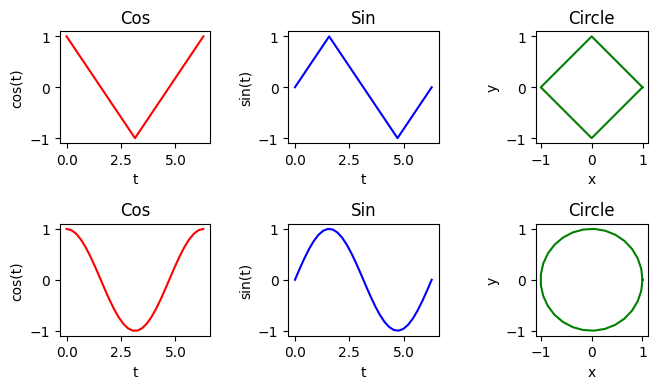

In [7]:
# TODO: Doing the plot.
#   1) Use plt.subplots to make a 2 x 3 sized set of plots
#   2) Call plot_one_row with the axes for the first row (axs1[0, :]) and your low-res data
#   3) Call plot_one_row with the axes for the second row (axs1[1, :]) and your hi-res data
#  You must use your plot function for full credit

nrows = 2
ncols = 3

# Note: axs1 should have size 2x3 (2 rows, 3 columns)
#   Do NOT rename axs1
fig, axs1 = plt.subplots(nrows, ncols, figsize=(7, 4))

plot_one_row(axs1[0,:], my_lowdim_data)
plot_one_row(axs1[1,:], my_highdim_data)

fig.tight_layout()
plt.show()


In [8]:
grader.check("plot_circle")

plot_circle results: All test cases passed!

## Plot something fun

TODO: Create a plot of a shape. Use a couple colors. Add text in the plot somewhere using text (see https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.text.html#matplotlib.axes.Axes.text). Use markers and lines.


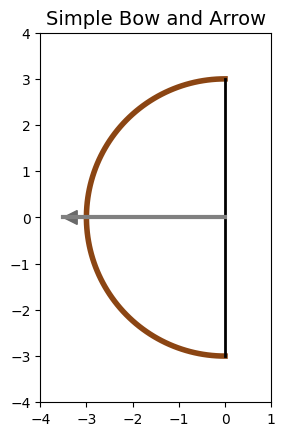

In [9]:
fig2, axs2 = plt.subplots(1, 1)

# --- Bow (a semicircle) ---
theta = np.linspace(-np.pi/2, np.pi/2, 100)
radius = 3
x_bow = -np.cos(theta) * radius  # flip horizontally
y_bow = np.sin(theta) * radius
axs2.plot(x_bow, y_bow, color='saddlebrown', linewidth=4, label='Bow')
# --- String (straight vertical line) ---
axs2.plot([0, 0], [-radius, radius], color='black', linewidth=2, label='String')

# --- Arrow shaft ---
arrow_x = np.linspace(0, -(radius+.5), 100)
arrow_y = np.zeros_like(arrow_x)
axs2.plot(arrow_x, arrow_y, color='gray', linewidth=3, label='Arrow')

# --- Arrowhead ---
arrow_tip_x_pos = -3.5
head_length = 0.3
head_width = 0.3
arrow_tip_x = [
    arrow_tip_x_pos, 
    arrow_tip_x_pos + head_length, 
    arrow_tip_x_pos + head_length
]
arrow_tip_y = [0, head_width/2, -head_width/2]
axs2.fill(arrow_tip_x, arrow_tip_y, color='dimgray')

# --- Style tweaks ---
axs2.set_aspect('equal')
axs2.set_xlim(-4, 1)
axs2.set_ylim(-4, 4)

axs2.set_title("Simple Bow and Arrow", fontsize=14)

plt.show()

In [10]:
grader.check("fun_shape")

fun_shape results: All test cases passed!

## Hours and collaborators
Required for every assignment - fill out before you hand-in.

Listing names and websites helps you to document who you worked with and what internet help you received in the case of any plagiarism issues. You should list names of anyone (in class or not) who has substantially helped you with an assignment - or anyone you have *helped*. You do not need to list TAs.

Listing hours helps us track if the assignments are too long.

In [11]:

# List of names (creates a set)
worked_with_names = {"ChatGPT, for the bow idea"}
# List of URLS F25(creates a set)
websites = {"ChatGPT.com"}
# Approximate number of hours, including lab/in-class time
hours = 1.5

In [12]:
grader.check("hours_collaborators")

hours_collaborators results: All test cases passed!

### To submit

- Do a restart then run all to make sure everything runs ok
- Save the file
- Submit just this .ipynb file through gradescope, Lecture activity 3, plotting
- You do NOT need to submit the data files - we will supply those
- Where there are given variable/file names (eg, foo = ...) DON'T change those, or the autograder will fail

If the Gradescope autograder fails, please check here first for common reasons for it to fail
    https://docs.google.com/presentation/d/1tYa5oycUiG4YhXUq5vHvPOpWJ4k_xUPp2rUNIL7Q9RI/edit?usp=sharing

Most likely failure for this assignment is not naming the data directory and files correctly; capitalization matters for the Gradescope grader. 

Second most likely cause for failure is reading in any file but ./Data/Wrist_torque_data.csv 

RUN YOUR FILE AND SAVE SO THE PLOTS SHOW